# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





Formative 2 – Principal Component Analysis

Dataset:
Global Competitiveness Index (GCI) 4.0

Student:
Constantine Akas

GitHub Repository:
https://github.com/codestantceasar/PCA-Formative-Assignment

Import Libraries

In [3]:
from google.colab import files

uploaded = files.upload()

Saving WEF_GCI_WIDEF.csv to WEF_GCI_WIDEF.csv


In [4]:
# Dataset file required:
# WEF_GCI_WIDEF.csv
# Place in the same directory as this notebook.
import pandas as pd
import numpy as np

Load Dataset

In [5]:
df = pd.read_csv("WEF_GCI_WIDEF.csv")

print(df.shape)
df.head()

(60531, 19)


,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL,2017,2018,2019
0,A,Annual,AGO,Angola,WEF_GCI_AIRINF,GCI 4.0: Air,0_TO_100,0-100 scale,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,NaN,32.23,32.53
1,A,Annual,AGO,Angola,WEF_GCI_AIRINF,GCI 4.0: Air,RANK,Rank,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,NaN,118.00,120.00
2,A,Annual,AGO,Angola,WEF_GCI_BANKCAPRWA,GCI 4.0: Banks' regulatory capital ratio (% of...,PT_AS_RKWT,Percentage of risk-weighted assets,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,NaN,NaN,18.04
3,A,Annual,AGO,Angola,WEF_GCI_BANKCAPRWA,GCI 4.0: Banks' regulatory capital ratio (% of...,RANK,Rank,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,NaN,NaN,54.00
4,A,Annual,AGO,Angola,WEF_GCI_BANKCAPRWA,GCI 4.0: Banks' regulatory capital ratio (% of...,SCORE,Score,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,100.0,100.00,100.00


Show Missing Values

In [6]:
print(df.isnull().sum())

FREQ                     0
FREQ_LABEL               0
REF_AREA                 0
REF_AREA_LABEL           0
INDICATOR                0
INDICATOR_LABEL          0
UNIT_MEASURE             0
UNIT_MEASURE_LABEL       0
DATABASE_ID              0
DATABASE_ID_LABEL        0
UNIT_MULT                0
UNIT_MULT_LABEL          0
OBS_STATUS               0
OBS_STATUS_LABEL         0
OBS_CONF                 0
OBS_CONF_LABEL           0
2017                  6210
2018                  4609
2019                  1433
dtype: int64


Prepare Data

In [7]:
score_df = df[df["UNIT_MEASURE"] == "SCORE"]

pivot_df = score_df.pivot_table(
    index="REF_AREA_LABEL",
    columns="INDICATOR",
    values="2019"
)

pivot_df = pivot_df.fillna(pivot_df.mean())

print(pivot_df.shape)
pivot_df.head()

(141, 99)


INDICATOR,WEF_GCI_BANKCAPRWA,WEF_GCI_BBSUBPC,WEF_GCI_CLEAREFF,WEF_GCI_CONFINTREG,WEF_GCI_CREDGDPGAP,WEF_GCI_DBREGPROPADMINQUAL,WEF_GCI_DEBDYNM,WEF_GCI_DOMCREDITGDP,WEF_GCI_ELECRATE,WEF_GCI_ENVTREATY,...,WEF_GCI_STARTBUSCOST,WEF_GCI_STARTBUSDAYS,WEF_GCI_TARIFCOMPL,WEF_GCI_TERRORISMINCIDENCEIDXGCI4,WEF_GCI_TFDUTY,WEF_GCI_TRADEMARK,WEF_GCI_TRANSPARENCYCPI,WEF_GCI_UNPANEPARTIDX,WEF_GCI_UNSAFEWATEREXPO,WEF_GCI_WORKRIGHT
REF_AREA_LABEL,,,,,,,,,,,,,,,,,,,,,
Albania,98.22,25.03,33.68,77.0,100.00,51.67,40.00,38.16,100.00,82.76,...,94.35,95.48,76.16,99.90,85.28,63.91,36.0,75.84,83.40,79.0
Algeria,100.00,14.51,28.26,33.0,98.49,25.00,44.98,24.33,99.12,65.52,...,94.10,82.91,92.30,98.21,0.00,50.97,35.0,20.22,89.53,57.0
Angola,100.00,0.71,14.29,53.0,100.00,23.33,38.82,21.12,43.00,62.07,...,93.05,64.32,66.16,95.33,54.44,0.00,19.0,43.26,23.32,71.0
Argentina,96.30,38.20,35.45,50.0,99.68,45.00,40.00,15.53,98.80,79.31,...,97.35,89.45,93.58,99.85,24.58,77.99,40.0,62.36,93.64,73.0
Armenia,100.00,23.54,39.34,67.0,100.00,68.33,50.00,51.23,100.00,65.52,...,99.60,96.98,53.14,99.89,71.56,71.67,35.0,56.74,98.86,71.5


Convert to NumPy

In [8]:
data_matrix = pivot_df.to_numpy()

print(data_matrix.shape)

(141, 99)


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

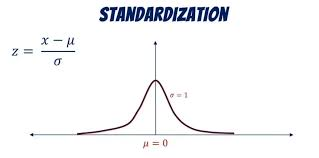


In [9]:
mean = np.mean(data_matrix, axis=0)
std = np.std(data_matrix, axis=0)

standardized_data = (data_matrix - mean) / std

standardized_data[:5]

array([[ 2.10369789e-01, -2.03630430e-01, -7.64536445e-01,
         1.21422426e+00,  4.09031433e-01, -8.65275403e-02,
        -1.01387762e+00, -6.21762294e-01,  5.75332550e-01,
         5.08044937e-01, -8.19057050e-01, -1.30215608e+00,
        -1.28693288e+00, -8.67417224e-01,  1.19514911e+00,
        -1.24221764e+00, -1.22281931e+00, -7.21864256e-02,
        -1.91591076e-01, -1.18600530e+00,  5.38274176e-01,
        -2.29913953e-01,  1.15711522e+00, -2.23255878e-01,
        -7.11940351e-01, -1.20661191e+00, -1.38939417e+00,
         9.84713076e-02,  7.56379726e-02,  7.26891158e-01,
        -7.44921527e-01,  8.17261866e-01,  2.78501726e+00,
         7.10431019e-01, -1.45908365e+00, -5.29029225e-01,
        -5.24794419e-01, -3.36077538e-02, -1.46347112e+00,
        -6.70253620e-01,  2.07320482e-01, -3.11843017e-01,
        -2.36226361e+00, -5.08747565e-01,  2.27896352e-01,
        -5.54731671e-01, -5.62572460e-01,  1.30158407e+00,
         8.47050320e-01, -7.51025233e-01, -1.60294131e-0

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [10]:
cov_matrix = np.cov(standardized_data, rowvar=False)

cov_matrix


array([[1.00714286, 0.16767337, 0.10532766, ..., 0.09477628, 0.12507623,
        0.01474927],
       [0.16767337, 1.00714286, 0.78221095, ..., 0.71070143, 0.76761338,
        0.31075448],
       [0.10532766, 0.78221095, 1.00714286, ..., 0.6819562 , 0.6179672 ,
        0.2878818 ],
       ...,
       [0.09477628, 0.71070143, 0.6819562 , ..., 1.00714286, 0.68168433,
        0.20751948],
       [0.12507623, 0.76761338, 0.6179672 , ..., 0.68168433, 1.00714286,
        0.19409932],
       [0.01474927, 0.31075448, 0.2878818 , ..., 0.20751948, 0.19409932,
        1.00714286]])

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

The covariance matrix measures how variables change together.

It helps identify relationships between competitiveness indicators and
determines which features contribute most to variance.

PCA uses the covariance matrix to discover the directions of maximum variance in the data.

These directions become the principal components used for dimensionality reduction

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [11]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

eigenvalues, eigenvectors

(array([4.79235447e+01, 8.94781622e+00, 3.49760124e+00, 3.37948486e+00,
        3.00502328e+00, 2.46054789e+00, 2.08138672e+00, 1.85039747e+00,
        1.68181805e+00, 1.36371526e+00, 1.30171500e+00, 1.21810637e+00,
        1.10124557e+00, 1.04968815e+00, 9.94511268e-01, 9.10561358e-01,
        8.87398442e-01, 8.19261938e-01, 8.03244180e-01, 7.32885598e-01,
        6.70870478e-01, 6.46746443e-01, 6.30132018e-01, 5.79145291e-01,
        5.54543580e-01, 5.25850129e-01, 4.92724696e-01, 4.62843594e-01,
        4.43435577e-01, 4.21353565e-01, 4.09494292e-01, 3.78585721e-01,
        3.69867964e-01, 3.57378463e-01, 3.45493841e-01, 3.33617153e-01,
        3.09238642e-01, 3.02923930e-01, 2.90316883e-01, 2.78751339e-01,
        2.57748479e-01, 2.48089732e-01, 2.36766139e-01, 2.30438628e-01,
        2.18601956e-01, 2.18139770e-01, 2.05655168e-01, 1.87318712e-01,
        1.82472254e-01, 1.75129146e-01, 1.70453166e-01, 1.51783404e-01,
        1.47475948e-01, 1.36370980e-01, 1.34956263e-01, 1.276668

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [12]:
sorted_indices = np.argsort(eigenvalues)[::-1]

sorted_eigenvectors = eigenvectors[:, sorted_indices]

sorted_eigenvectors

array([[-0.02634788, -0.01536103,  0.19810522, ...,  0.00111828,
        -0.03374743, -0.02002786],
       [-0.11419543,  0.15227348,  0.04706271, ...,  0.05277493,
        -0.01514069,  0.04318745],
       [-0.12468247,  0.06528433, -0.04610219, ...,  0.09226984,
         0.02288031,  0.00782318],
       ...,
       [-0.10828527,  0.10136758, -0.0797585 , ...,  0.04007599,
         0.02667258,  0.04937809],
       [-0.10280045,  0.1570081 ,  0.02004407, ...,  0.13986391,
         0.10913568,  0.0209366 ],
       [-0.03310803,  0.12952672,  0.13267282, ...,  0.07650364,
         0.02106956,  0.03475042]])

Explained variance shows how much information each principal component retains from the original dataset.

Components with larger eigenvalues explain more variance and
are considered more important.

PCA ranks components by explained variance so that the most informative components are kept.

This allows dimensionality reduction while preserving most of the original information.

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [13]:
num_components = 34

principal_components = sorted_eigenvectors[:, :num_components]

reduced_data = np.dot(
    standardized_data,
    principal_components
)

reduced_data[:5]

array([[ 2.20755738e+00,  1.18345611e+00,  2.62913797e+00,
         2.28301425e+00,  7.09978561e-01,  2.27234324e+00,
         6.45421837e-01, -2.36975613e+00,  1.38269985e+00,
         5.06525474e-01,  5.35286370e-01, -1.81276531e+00,
        -1.13396798e+00,  1.64084693e+00, -1.35879975e+00,
         6.45826729e-01,  1.69327877e-01, -1.59645022e+00,
         1.01790788e+00, -1.25905644e+00,  7.76453946e-01,
         5.72121654e-01,  5.29579413e-01,  9.82341785e-01,
        -3.96255913e-01, -3.53271958e-01,  5.53636189e-01,
        -1.09710886e+00, -1.42488848e-01,  8.51124775e-02,
         4.16201092e-01, -1.18848762e+00,  1.38494833e+00,
         8.74569293e-02],
       [ 3.82664032e+00, -1.31210859e+00, -5.38280427e-01,
         6.54343049e-01, -1.37834457e+00, -2.84807645e+00,
         1.64161171e+00, -7.95125885e-01,  8.75241814e-01,
        -5.85874365e-01,  7.59042094e-01,  7.56600764e-01,
        -4.29038547e-01, -9.09219117e-01,  1.14641610e+00,
         2.22693167e-02,  1.78

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [14]:
print(f"Reduced Data Shape: {reduced_data.shape}")

reduced_data[:5]

Reduced Data Shape: (141, 34)


array([[ 2.20755738e+00,  1.18345611e+00,  2.62913797e+00,
         2.28301425e+00,  7.09978561e-01,  2.27234324e+00,
         6.45421837e-01, -2.36975613e+00,  1.38269985e+00,
         5.06525474e-01,  5.35286370e-01, -1.81276531e+00,
        -1.13396798e+00,  1.64084693e+00, -1.35879975e+00,
         6.45826729e-01,  1.69327877e-01, -1.59645022e+00,
         1.01790788e+00, -1.25905644e+00,  7.76453946e-01,
         5.72121654e-01,  5.29579413e-01,  9.82341785e-01,
        -3.96255913e-01, -3.53271958e-01,  5.53636189e-01,
        -1.09710886e+00, -1.42488848e-01,  8.51124775e-02,
         4.16201092e-01, -1.18848762e+00,  1.38494833e+00,
         8.74569293e-02],
       [ 3.82664032e+00, -1.31210859e+00, -5.38280427e-01,
         6.54343049e-01, -1.37834457e+00, -2.84807645e+00,
         1.64161171e+00, -7.95125885e-01,  8.75241814e-01,
        -5.85874365e-01,  7.59042094e-01,  7.56600764e-01,
        -4.29038547e-01, -9.09219117e-01,  1.14641610e+00,
         2.22693167e-02,  1.78

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

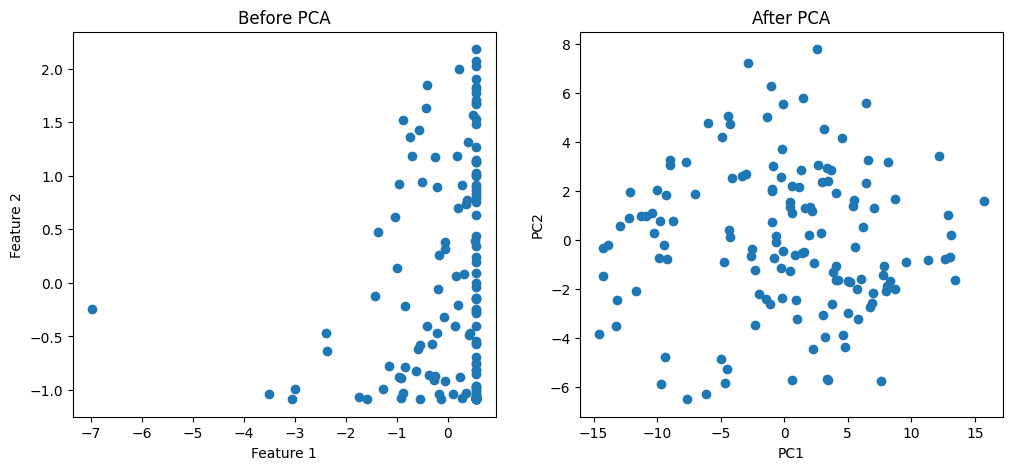

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Original data
plt.subplot(1,2,1)
plt.scatter(
    standardized_data[:,0],
    standardized_data[:,1]
)
plt.title("Before PCA")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# PCA data
plt.subplot(1,2,2)
plt.scatter(
    reduced_data[:,0],
    reduced_data[:,1]
)

plt.title("After PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1.
Before PCA, the dataset is represented using the original competitiveness indicators.

After PCA, the data is transformed into principal components that capture most of the variance.

The overall structure of the countries remains visible, but the data is represented in fewer dimensions.

PC1 captures the largest amount of variation while PC2 captures the second largest amount.

2.
Why 34 Components?
I selected 34 principal components because they retain approximately 90% of the total variance in the dataset.

This means most of the information is preserved while reducing the original 99 indicators to 34 components.

The tradeoff is that around 10% of the variance is discarded, which may contain smaller patterns or country-specific details.

3.
The dataset measures competitiveness indicators such as infrastructure, innovation, institutions, and financial systems.

By reducing dimensions, some detailed information from less influential indicators is lost.

Small country-specific variations may no longer be represented, but the major competitiveness patterns are preserved.

GitHub Repository:
https://github.com/codestantceasar/PCA-Formative-Assignment

# Contribution Sheet

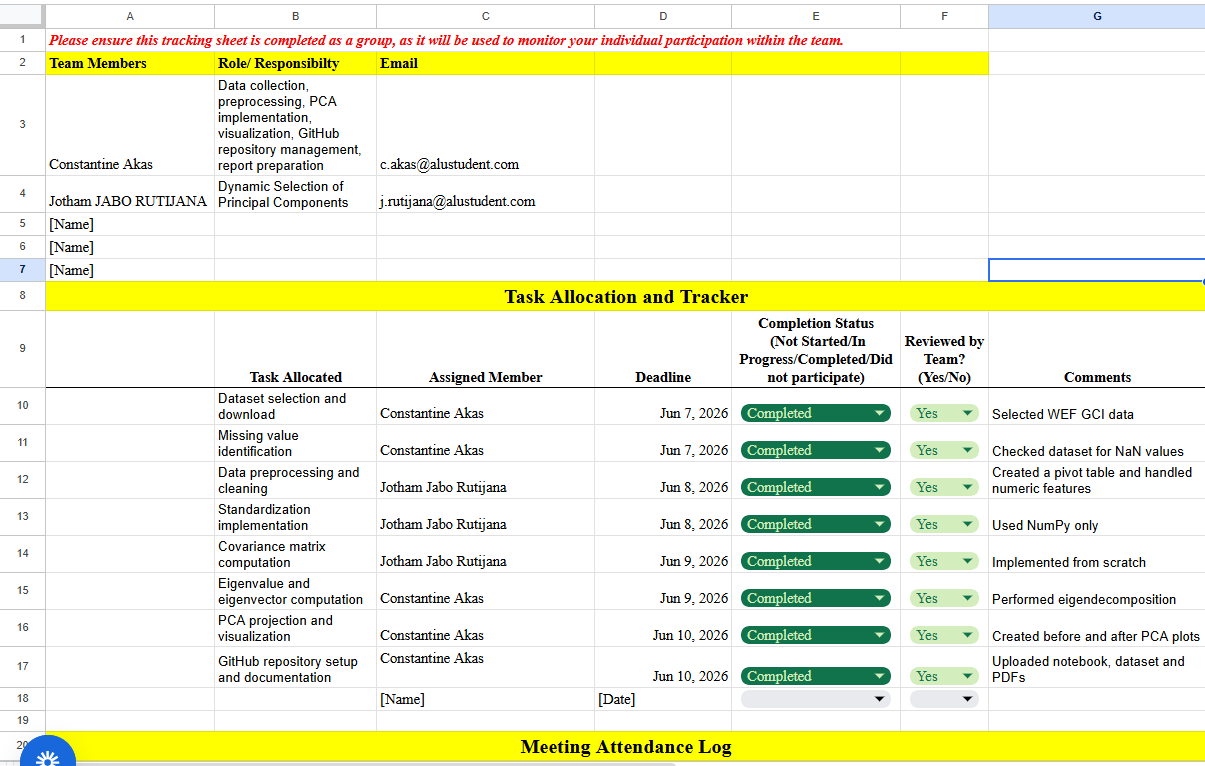


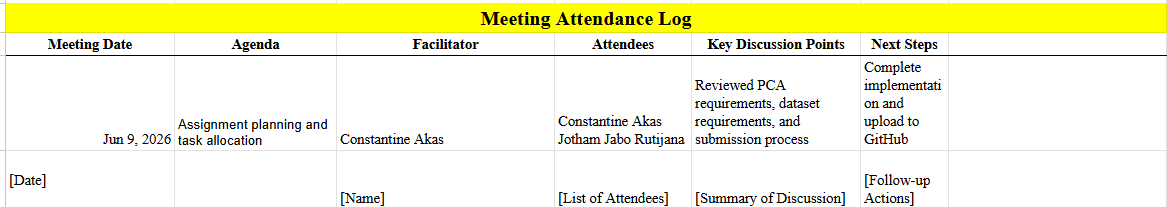